In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn

In [ ]:
# Load your processed dataset
df = pd.read_csv("D:/Percia_MTech/GUVI/python/Projects/patrol_IQ/data/chicago_crime_featured.csv")

features = [
    'latitude', 'longitude', 'hour', 'day_of_week', 'month', 
    'district', 'ward', 'community_area', 'x_coordinate', 'y_coordinate',
    'arrest', 'domestic', 'year'
]
df_num = df[features].dropna()

print("✅ Feature matrix shape:", df_num.shape)


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Satheesh\AppData\Local\Temp\ipykernel_17200\3974393505.py:2: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv("D:\Percia_MTech\GUVI\python\Projects\patrol_IQ\data\chicago_crime_featured.csv")


✅ Feature matrix shape: (466741, 13)


In [3]:
# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"]
)

pca_df.to_csv("D:/Percia_MTech/GUVI/python/Projects/patrol_IQ/data/pca_components.csv", index=False)
print("Saved: data/pca_components.csv")

Principal Component Analysis

2025/11/10 15:06:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/10 15:06:14 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/11/10 15:06:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



🔝 Top 5 Most Influential Features:
month          0.297800
day_of_week    0.278142
arrest         0.230139
longitude      0.222202
year           0.221736
dtype: float64


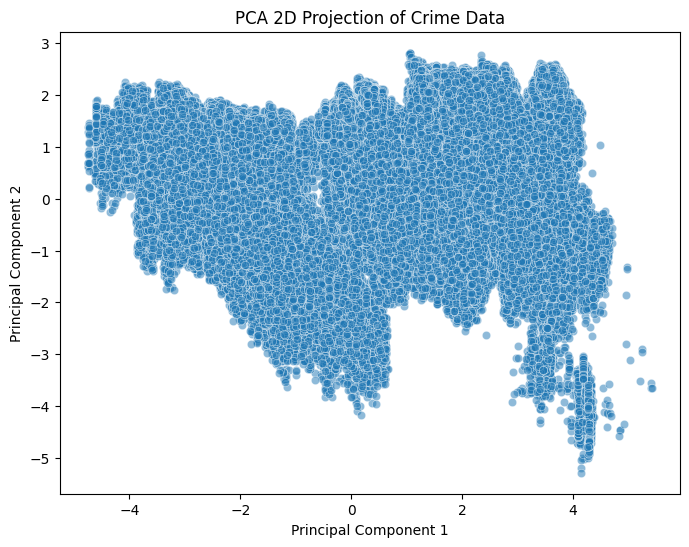

🏃 View run PCA_Reduction at: http://127.0.0.1:5000/#/experiments/497083060675887000/runs/b9c2bb7430344aa6bff644ff3af1f0d5
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/497083060675887000


In [6]:
mlflow.set_experiment("Crime Hotspot Clustering V1")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

with mlflow.start_run(run_name="PCA_Reduction"):
    pca = PCA(n_components=5, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    explained_variance = np.sum(pca.explained_variance_ratio_) * 100
    
    mlflow.log_param("method", "PCA")
    mlflow.log_metric("explained_variance_pct", explained_variance)
    mlflow.sklearn.log_model(pca, "PCA_Model")

    # Top 5 features driving PCA
    loadings = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(pca.n_components_)],
        index=df_num.columns
    )
    importance = loadings.abs().mean(axis=1).sort_values(ascending=False).head(5)
    print("\n🔝 Top 5 Most Influential Features:")
    print(importance)
    mlflow.log_text(importance.to_string(), "top_features.txt")

    # 2D PCA Plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], alpha=0.5)
    plt.title("PCA 2D Projection of Crime Data")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

t-SNE

2025/11/10 16:24:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/10 16:24:07 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/11/10 16:24:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


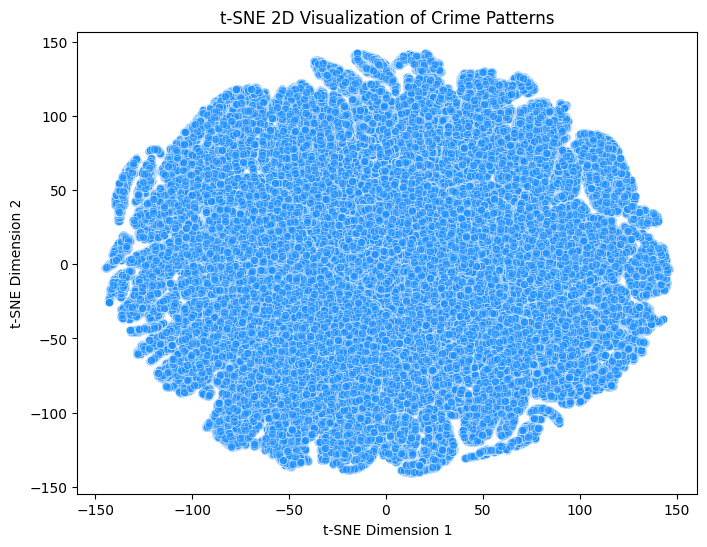

🏃 View run tSNE_Visualization at: http://127.0.0.1:5000/#/experiments/497083060675887000/runs/bf3ebb40dafc44e6bd2a21387d319123
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/497083060675887000


In [7]:
mlflow.set_experiment("Crime Hotspot Clustering V1")
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

with mlflow.start_run(run_name="tSNE_Visualization"):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_pca[:, :3])  # use top 3 PCA components

    mlflow.log_param("method", "tSNE")
    mlflow.log_param("perplexity", 30)
    mlflow.sklearn.log_model(tsne, "tSNE_Model")

    plt.figure(figsize=(8,6))
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], alpha=0.5, color="dodgerblue")
    plt.title("t-SNE 2D Visualization of Crime Patterns")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()
